# Introduction
Mental health discourse increasingly occurs in informal digital spaces, where individuals express emotional distress in unstructured language. Detecting stress signals in such contexts presents both a linguistic and modelling challenge as stress is subjective, indirectly expressed, and shaped by community norms.

In this assignment, we frame stress detection as a binary classification task using the Dreaddit dataset. Each Reddit post is labelled as either stressed (1) or non-stressed (0). The objective is to build predictive models that distinguish between these two classes based on textual and psychologically grounded linguistic features.

Performance is evaluated primarily using F1-score on the held-out test set. The F1-score balances precision and recall, ensuring that the model performs well in both detecting stressed posts and avoiding incorrect classifications. Beyond predictive accuracy, emphasis is placed on interpretability, subgroup behaviour, and critical analysis of model limitations.

link to GitHub: https://github.com/rawrbyn/DSA4262/tree/main/Assignment2 

# Set Up & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

train_df = pd.read_csv("dreaddit-train.csv")
test_df = pd.read_csv("dreaddit-test.csv")

print(train_df.shape)
print(test_df.shape)

(2838, 116)
(715, 116)


# Stage 1: Exploratory Data Analysis (EDA)

### Dataset Overview

In [2]:
train_df.columns

Index(['subreddit', 'post_id', 'sentence_range', 'text', 'id', 'label',
       'confidence', 'social_timestamp', 'social_karma', 'syntax_ari',
       ...
       'lex_dal_min_pleasantness', 'lex_dal_min_activation',
       'lex_dal_min_imagery', 'lex_dal_avg_activation', 'lex_dal_avg_imagery',
       'lex_dal_avg_pleasantness', 'social_upvote_ratio',
       'social_num_comments', 'syntax_fk_grade', 'sentiment'],
      dtype='object', length=116)

In [3]:
train_df['subreddit'].value_counts()

subreddit
ptsd                584
relationships       552
anxiety             503
domesticviolence    316
assistance          289
survivorsofabuse    245
homeless            168
almosthomeless       80
stress               64
food_pantry          37
Name: count, dtype: int64

We have an overview of the distribution of posts across the different subreddits found in the dataset. The subreddits with the greatest counts in the Dreaddit dataset are ptsd, relationships, followed by anxiety.

In [4]:
train_df['label'].value_counts(normalize=True)

label
1    0.524313
0    0.475687
Name: proportion, dtype: float64

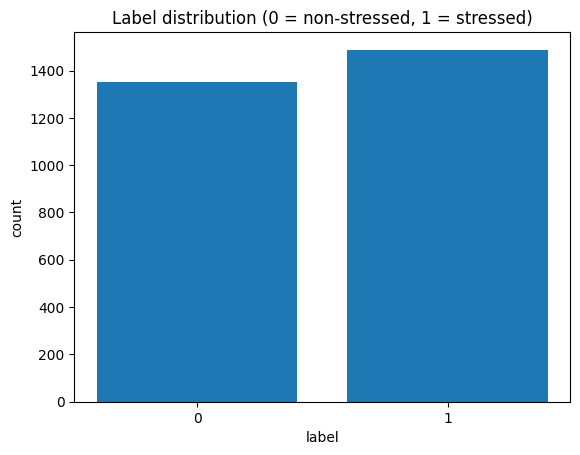

In [5]:
df = train_df.copy()

counts = df["label"].value_counts().sort_index()
plt.bar(counts.index.astype(str), counts.values)
plt.title("Label distribution (0 = non-stressed, 1 = stressed)")
plt.xlabel("label"); plt.ylabel("count")
plt.show()

We observe above that the dataset is approximately balanced, with 52.4% stressed posts and 47.6% non-stressed posts. This near parity reduces concerns about severe class imbalance and suggests that accuracy would not be heavily biased toward the majority class. This near-balanced distribution also suggests that model performance will be driven more by feature separability than by class prior differences. Nevertheless, F1-score remains the primary evaluation metric, as both false positives and false negatives carry meaningful implications in stress detection.

### Stress rate by Subreddit

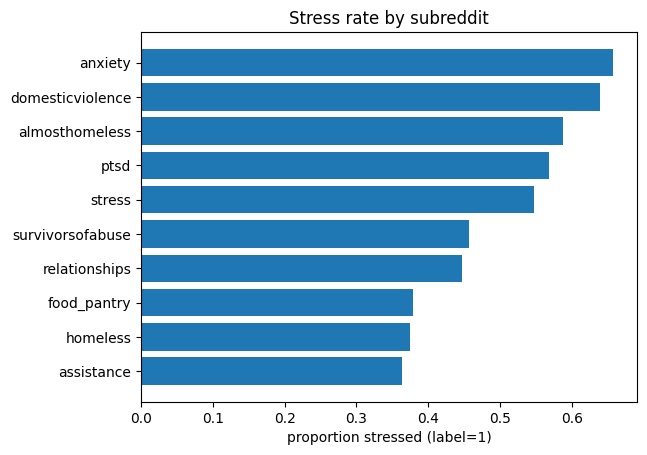

In [6]:
top = df["subreddit"].value_counts()
sub = df[df["subreddit"].isin(top.index)]
stress_rate = sub.groupby("subreddit")["label"].mean().sort_values()

plt.barh(stress_rate.index, stress_rate.values)
plt.title("Stress rate by subreddit")
plt.xlabel("proportion stressed (label=1)")
plt.show()


Stress prevalence varies substantially across subreddits, as we see that mental health–focused subreddits such as _anxiety_, _domesticviolence_, and _ptsd_ exhibit higher proportions of stressed posts, whereas resource-oriented communities such as _food_pantry_, _homeless_, and _assistance_ show comparatively lower stress rates.

This variation highlights the role of community norms and topical focus in shaping how stress is expressed. Importantly, it suggests that a predictive model may partially learn subreddit-specific linguistic patterns rather than stress-specific features. Such contextual dependence raises potential concerns about generalisation to new communities and underscores the need to evaluate model performance across subreddits.

### Automated Readibility Index (ARI) Comparison by label

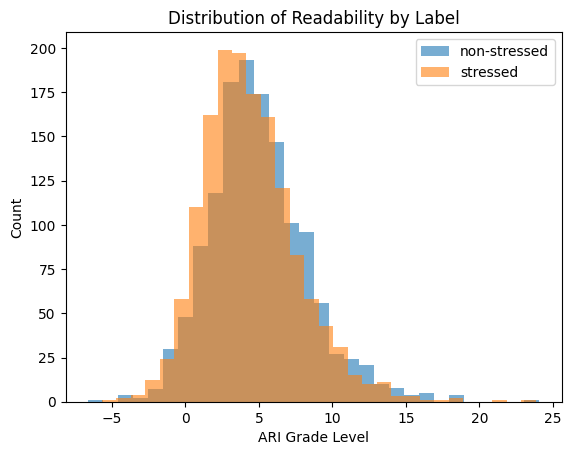

In [7]:
plt.hist(df[df.label==0]["syntax_ari"], bins=30, alpha=0.6, label="non-stressed")
plt.hist(df[df.label==1]["syntax_ari"], bins=30, alpha=0.6, label="stressed")
plt.xlabel("ARI Grade Level")
plt.ylabel("Count")
plt.title("Distribution of Readability by Label")
plt.legend()
plt.show()


The distribution of readability (measured via ARI level) shows substantial overlap between stressed and non-stressed posts. Although stressed posts exhibit a slight leftward shift, suggesting marginally lower syntactic complexity, the difference is small relative to the overall spread of both distributions. This indicates weak discriminative power when considered in isolation.

In [8]:
df["word_count"] = df["text"].str.split().str.len()

df[["syntax_ari", "word_count"]].corr()

,syntax_ari,word_count
syntax_ari,1.000000,0.544315
word_count,0.544315,1.000000


Furthermore, readability demonstrates a moderate positive correlation with word count (r ≈ 0.54), indicating that variation in ARI partially reflects post length rather than purely structural complexity. In other words, longer posts tend to appear more “complex” regardless of psychological state. This suggests that posts may appear more complex simply because they are longer, not because the writer is more or less stressed.

In [9]:
df.groupby("subreddit")["syntax_ari"].mean().sort_values().head(10)

subreddit
food_pantry         3.880335
domesticviolence    4.212670
relationships       4.403039
almosthomeless      4.453025
anxiety             4.548604
ptsd                4.760447
homeless            4.809603
assistance          4.947279
survivorsofabuse    5.463756
stress              6.062850
Name: syntax_ari, dtype: float64

In addition, average ARI varies across subreddits, highlighting that writing style and structural complexity are influenced by community norms. Readability differences may therefore reflect contextual writing conventions rather than genuine stress expression.

Taken together, these findings suggest that syntactic complexity alone does not meaningfully differentiate stressed from non-stressed language. In practical deployment settings, relying heavily on readability would likely yield unstable or misleading predictions, reinforcing the need for richer lexical and psychological features.

### Sentiment distribution by label

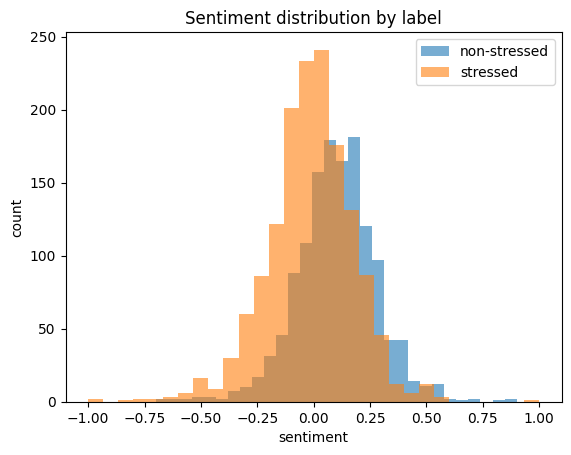

In [10]:
plt.hist(df[df.label==0]["sentiment"].dropna(), bins=30, alpha=0.6, label="non-stressed")
plt.hist(df[df.label==1]["sentiment"].dropna(), bins=30, alpha=0.6, label="stressed")
plt.title("Sentiment distribution by label")
plt.xlabel("sentiment"); plt.ylabel("count")
plt.legend()
plt.show()

The sentiment distribution shows clearer separation between stressed and non-stressed posts compared to structural features such as readability. Stressed posts are generally shifted toward more negative sentiment values, while non-stressed posts exhibit more neutral and positive tone.

However, substantial overlap remains between the two distributions, indicating that sentiment alone cannot fully distinguish stress expression. While negative affect is associated with stress, not all negative posts are labeled stressed, and some stressed posts contain mixed or neutral emotional tone.

These findings suggest that sentiment provides meaningful but incomplete signal for stress detection, reinforcing the need for additional lexical and psychological features.

### Average LIWC Feature Comparison by Label

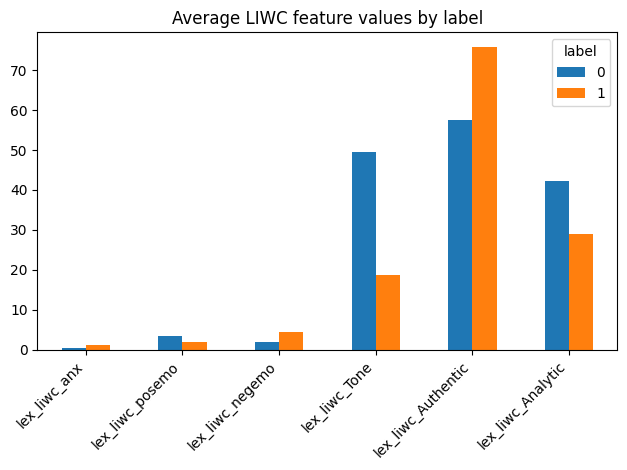

In [11]:
features = ["lex_liwc_anx", "lex_liwc_posemo", "lex_liwc_negemo", "lex_liwc_Tone", "lex_liwc_Authentic", "lex_liwc_Analytic"]

mean_table = df.groupby("label")[features].mean()
mean_table

mean_table.T.plot(kind="bar")
plt.title("Average LIWC feature values by label")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The LIWC feature analysis reveals differences in both emotional content and linguistic style between stressed and non-stressed posts. Stressed posts exhibit higher levels of anxiety-related (_lex_liwc_anx_) and negative emotion words (_lex_liwc_negemo_), alongside lower positive emotion (_lex_liwc_posemo_) and emotional tone (_lex_liwc_Tone_). These findings align with psychological expectations that stress is associated with heightened negative affect and reduced positive emotional expression.

Beyond affective tone, stylistic differences are also evident. Stressed posts show higher scores on the Authentic dimension (_lex_liwc_Authentic_), suggesting greater degree of personal disclosure and honesty (Boyd et al., 2022). In contrast, they exhibit lower Analytic scores (_lex_liwc_Analytic_), suggesting relatively less logical thinking. This pattern may reflect a shift toward more emotionally driven yet genuine communication under stress.

Together, these findings suggest that stress expression is reflected not only in affective word usage but also in broader linguistic style. Compared to structural measures such as readability, these psychologically grounded features exhibit clearer group-level differences between stressed and non-stressed posts, suggesting they may provide more informative signals for predictive modelling.

### Correlation Analysis of Selected Features

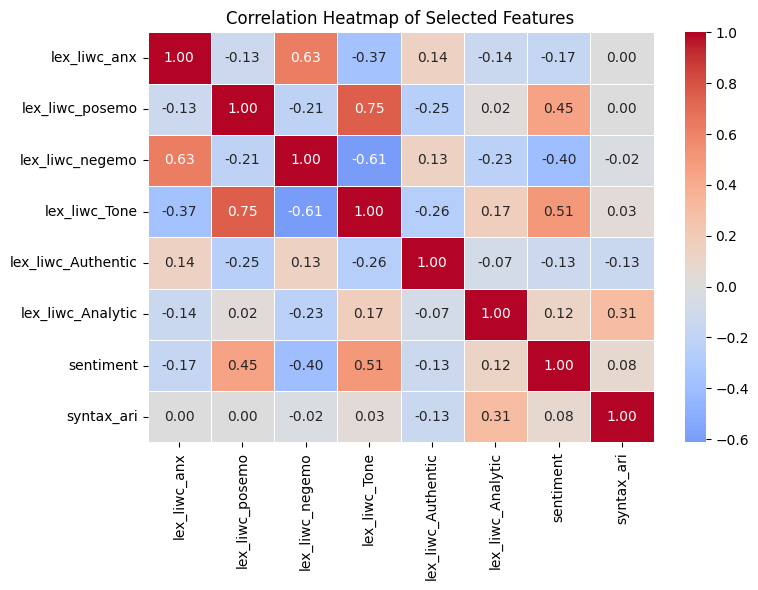

In [12]:
features = [
    "lex_liwc_anx", "lex_liwc_posemo", "lex_liwc_negemo",
    "lex_liwc_Tone", "lex_liwc_Authentic",
    "lex_liwc_Analytic", "sentiment", "syntax_ari"
]

corr = df[features].corr()

plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    annot=True,          
    fmt=".2f",           
    linewidths=0.5
)

plt.title("Correlation Heatmap of Selected Features")
plt.tight_layout()
plt.show()

The correlation heatmap reveals a coherent emotional cluster among LIWC features. Anxiety (_lex_liwc_anx_) and negative emotion (_lex_liwc_negemo_) are strongly positively correlated (0.63), while Tone (_lex_liwc_Tone_) is strongly positively correlated with positive emotion (_lex_liwc_posemo_) (0.75) and negatively correlated with negative emotion (_lex_liwc_negemo_) (-0.61). This reflects expected psychological structure in the data.

Sentiment shows moderate correlations with Tone and emotional LIWC features, suggesting partial redundancy between sentiment polarity and LIWC-derived emotional measures.

In contrast, structural complexity (syntax_ari) exhibits minimal correlation with emotional features, indicating that syntactic complexity is largely independent of affective content. This supports earlier findings that structural features capture different dimensions of language compared to emotional and stylistic measures.

### EDA Summary and Modelling Implications
Overall, the exploratory analysis suggests that stress expression in Reddit posts is more strongly reflected in affective and stylistic lexical features than in structural complexity. Readability (ARI) shows substantial overlap between stressed and non-stressed posts, indicating limited discriminative power. In contrast, LIWC features such as anxiety, negative emotion, tone, and authenticity exhibit clearer group-level differences, aligning with psychological expectations about stress expression. Additionally, variation in stress rates across subreddits highlights the contextual nature of language use and raises potential generalisation considerations.

These findings suggest that predictive modelling should prioritise emotionally and psychologically grounded linguistic features, while treating structural measures such as readability with caution. We now proceed to train and evaluate classification models to assess how effectively these linguistic signals can be translated into predictive performance.


# Stage 2: Data Processing

This section defines the preprocessing pipeline used for all models. 
All transformations are implemented within scikit-learn pipelines to ensure reproducibility and prevent data leakage during cross-validation.

The modelling pipeline follows several preprocessing steps:

1. **Train–Test Separation**: The provided Dreaddit training and test sets are kept strictly separate. All model selection and cross-validation are performed on the training set only to prevent data leakage. The test set is used once at the end.

2. **Cross-Validation Strategy**: Stratified k-fold cross-validation is used to preserve class proportions within folds and provide robust performance estimates.

3. **Text Representation**: Raw text is converted into numerical representations using TF-IDF vectorisation, which captures individual words (unigrams) as well as two-word phrases (bigrams) to retain limited contextual information.

4. **Psychological and Numerical Features**: Selected LIWC-derived features, sentiment scores, and readability metrics are standardised before modelling to ensure comparable scales.

5. **Class Imbalance Handling**: Although the dataset is approximately balanced, class weights are used during training to ensure robustness to minor imbalance.

In [13]:
# reproducibility
import numpy as np
import random

# Reproducibility
np.random.seed(42)
random.seed(42)

In [14]:
# Stratified K-Fold Cross-Validation
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [15]:
# Define feature groups
text_column = "text"

liwc_features = [
    "lex_liwc_anx",
    "lex_liwc_posemo",
    "lex_liwc_negemo",
    "lex_liwc_Tone",
    "lex_liwc_Authentic",
    "lex_liwc_Analytic",
    "sentiment",
    "syntax_ari"
]

In [16]:
# Define text vectoriser
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    ngram_range=(1,2),
    min_df=5,
    max_df=0.9
)

In [17]:
# Define numeric preprocessing
from sklearn.preprocessing import StandardScaler

numeric_scaler = StandardScaler()

In [18]:
# Define combined preprocessor
from sklearn.compose import ColumnTransformer

preprocessor_combined = ColumnTransformer(
    transformers=[
        ("text", tfidf, text_column),
        ("num", numeric_scaler, liwc_features)
    ],
    remainder="drop"
)

# Stage 3: Modelling

## Model Architecture and Rationale
Based on the exploratory analysis, stress expression in Reddit posts appears to be more strongly reflected in lexical and affective language patterns than in structural complexity alone. Accordingly, the modelling strategy prioritises interpretable linear models that can capture high-dimensional lexical signals while remaining analytically transparent.

Three progressively richer model configurations are evaluated:

**Text-only model (TF-IDF + Logistic Regression)**
Raw text is represented using TF-IDF vectorisation, capturing both individual words (unigrams) and two-word phrases (bigrams). Logistic regression is selected as a baseline classifier because it performs well in high-dimensional text settings, produces probabilistic outputs, and allows direct interpretation through feature coefficients. This model serves as a strong lexical baseline.

**LIWC-only model (Psychological and stylistic features)**
To examine whether summary-level linguistic signals alone is sufficient to predict stress, we use selected LIWC-based affective and stylistic features, along with sentiment and readability metrics. LIWC is grounded in psycholinguistic theory and is widely used to measure emotional, cognitive, and social patterns in language (Tausczik & Pennebaker, 2010). By excluding detailed word-level features, this model allows us to assess how much predictive value psychologically grounded indicators provide on their own.

**Combined model (Text + LIWC features)**
A combined feature space integrates TF-IDF lexical features with LIWC and related numerical features. This configuration assesses whether psychologically grounded features provide complementary predictive value beyond lexical n-grams.


All models are implemented within scikit-learn pipelines to ensure reproducibility and prevent data leakage during cross-validation. Stratified 5-fold cross-validation is used for performance estimation, with F1-score as the primary metric.

In addition to logistic regression, alternative classifiers such as Linear Support Vector Machine (SVM) and Random Forest (for LIWC features) are explored to assess whether margin-based or nonlinear modelling offers additional benefit. Linear SVM is included because such models are widely used as strong baselines in text classification research (Wang & Manning, 2012).

A feature ablation experiment is also conducted by removing selected explicit emotion-related words before vectorisation. This allows us to examine whether stress detection depends primarily on overt affective vocabulary or broader contextual linguistic patterns.

Model complexity is intentionally constrained to prioritise interpretability and analytical clarity, consistent with the assignment’s emphasis on sense-making rather than leaderboard optimisation.

## Stage 3a: Baseline Architecture

We first evaluate logistic regression across three feature configurations: text-only, LIWC-only, and combined representations. Logistic regression serves as the primary baseline architecture due to its robustness, interpretability, and suitability for high-dimensional sparse text features.

### Model 1: Text-Only Baseline

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

pipeline_text = Pipeline([
    ("tfidf", tfidf),
    ("clf", LogisticRegression(
        class_weight="balanced",
        max_iter=1000
    ))
])

scores_text = cross_val_score(
    pipeline_text,
    train_df["text"],
    train_df["label"],
    cv=cv,
    scoring="f1"
)

print("Text-only F1:", scores_text.mean())
print("Std:", scores_text.std())

Text-only F1: 0.7647481347845815
Std: 0.012463778786474259


### Model 2: LIWC-Only Model

In [20]:
pipeline_liwc = Pipeline([
    ("scaler", numeric_scaler),
    ("clf", LogisticRegression(
        class_weight="balanced",
        max_iter=1000
    ))
])

scores_liwc = cross_val_score(
    pipeline_liwc,
    train_df[liwc_features],
    train_df["label"],
    cv=cv,
    scoring="f1"
)

print("LIWC-only F1:", scores_liwc.mean())
print("Std:", scores_liwc.std())

LIWC-only F1: 0.736557342311381
Std: 0.008073623304711914


### Model 3: Combined Model

In [21]:
pipeline_combined = Pipeline([
    ("preprocessor", preprocessor_combined),
    ("clf", LogisticRegression(
        class_weight="balanced",
        max_iter=1000
    ))
])

scores_combined = cross_val_score(
    pipeline_combined,
    train_df,
    train_df["label"],
    cv=cv,
    scoring="f1"
)

print("Combined F1:", scores_combined.mean())
print("Std:", scores_combined.std())


Combined F1: 0.7757251055414915
Std: 0.010952090938714154


### Baseline Architecture Comparison

In [22]:
baseline_results = pd.DataFrame({
    "Model": ["Text-only (TF-IDF)", 
              "LIWC-only", 
              "Combined (Text + LIWC)"],
    "Mean F1": [
        scores_text.mean(),
        scores_liwc.mean(),
        scores_combined.mean()
    ],
    "Std (CV)": [
        scores_text.std(),
        scores_liwc.std(),
        scores_combined.std()
    ]
}); baseline_results

,Model,Mean F1,Std (CV)
0,Text-only (TF-IDF),0.764748,0.012464
1,LIWC-only,0.736557,0.008074
2,Combined (Text + LIWC),0.775725,0.010952


The LIWC-only model achieves an F1-score of 0.737, indicating that psychologically grounded features alone capture substantial stress-related signal. This supports earlier exploratory findings that emotional and stylistic language patterns differ between stressed and non-stressed posts.

The text-only TF-IDF model achieves a higher F1-score of 0.765, suggesting that fine-grained lexical patterns provide richer predictive information than aggregated psychological metrics.

The combined model achieves a modest improvement to 0.776, indicating that LIWC-derived features contribute incremental predictive value beyond lexical n-grams. However, the relatively small gain suggests that much of the psychological signal is already implicitly encoded within word-level representations.

Overall, stress detection appears to benefit primarily from detailed lexical patterns, with psychologically grounded features providing complementary but limited additional value.

## Stage 3b: Alternative Classifiers

To assess whether different learning assumptions provide additional benefits, we evaluate a Linear SVM (text-only) and a Random Forest model (LIWC-only). These experiments test whether margin-based or nonlinear modelling improves predictive performance relative to the baseline logistic framework.

### Linear SVM

In [23]:
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

pipeline_svm = Pipeline([
    ("tfidf", tfidf),
    ("clf", LinearSVC())
])

scores_svm = cross_val_score(
    pipeline_svm,
    train_df["text"],
    train_df["label"],
    cv=cv,
    scoring="f1"
)

print("Linear SVM F1:", scores_svm.mean())
print("Std:", scores_svm.std())


Linear SVM F1: 0.7533503270310538
Std: 0.007527371789006258


### Random Forest

In [24]:
from sklearn.ensemble import RandomForestClassifier

pipeline_rf = Pipeline([
    ("clf", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

scores_rf = cross_val_score(
    pipeline_rf,
    train_df[liwc_features],
    train_df["label"],
    cv=cv,
    scoring="f1"
)

print("Random Forest (LIWC-only) F1:", scores_rf.mean())
print("Std:", scores_rf.std())


Random Forest (LIWC-only) F1: 0.7332944810203542
Std: 0.01080195724842491


## Stage 3c: Feature Ablation Study
To examine whether the model relies heavily on explicit emotional vocabulary, we conduct a feature ablation experiment by removing selected emotion-related words from the text before training the logistic regression model. This analysis evaluates whether stress detection depends primarily on overt emotion terms or broader contextual linguistic patterns.

### Text-Without-Emotion-Words

In [25]:
emotion_words = [
    "stress", "stressed", "anxious", "anxiety",
    "worried", "worry", "depressed", "overwhelmed",
    "panic", "panicking", "afraid", "fear"
]

import re

def remove_emotion_words(text):
    pattern = r"\b(" + "|".join(emotion_words) + r")\b"
    return re.sub(pattern, "", text, flags=re.IGNORECASE)

train_df["text_no_emotion"] = train_df["text"].apply(remove_emotion_words)

pipeline_text_no_emotion = Pipeline([
    ("tfidf", tfidf),
    ("clf", LogisticRegression(
        class_weight="balanced",
        max_iter=1000
    ))
])

scores_no_emotion = cross_val_score(
    pipeline_text_no_emotion,
    train_df["text_no_emotion"],
    train_df["label"],
    cv=cv,
    scoring="f1"
)

print("Text without emotion words F1:", scores_no_emotion.mean())
print("Std:", scores_no_emotion.std())

Text without emotion words F1: 0.7596934336952029
Std: 0.013947998124001685


## Comparisons of All Models

In [26]:
results_all = pd.DataFrame({
    "Model": [
        "Combined (Text + LIWC)",
        "Text-only (Logistic Regression)",
        "Text without emotion words",
        "Linear SVM (Text-only)",
        "LIWC-only (Logistic Regression)",
        "Random Forest (LIWC-only)"
    ],
    "Mean F1": [
        scores_combined.mean(),
        scores_text.mean(),
        scores_no_emotion.mean(),
        scores_svm.mean(),
        scores_liwc.mean(),
        scores_rf.mean()
    ],
    "Std (CV)": [
        scores_combined.std(),
        scores_text.std(),
        scores_no_emotion.std(),
        scores_svm.std(),
        scores_liwc.std(),
        scores_rf.std()
    ]
})

results_ranked = results_all.sort_values(
    by="Mean F1",
    ascending=False
).reset_index(drop=True)

results_ranked["Rank"] = results_ranked.index + 1

results_ranked = results_ranked[["Rank", "Model", "Mean F1", "Std (CV)"]]

results_ranked["Mean F1"] = results_ranked["Mean F1"].round(3)
results_ranked["Std (CV)"] = results_ranked["Std (CV)"].round(3)

results_ranked

,Rank,Model,Mean F1,Std (CV)
0,1,Combined (Text + LIWC),0.776,0.011
1,2,Text-only (Logistic Regression),0.765,0.012
2,3,Text without emotion words,0.760,0.014
3,4,Linear SVM (Text-only),0.753,0.008
4,5,LIWC-only (Logistic Regression),0.737,0.008
5,6,Random Forest (LIWC-only),0.733,0.011


Linear SVM yields slightly lower performance (F1 = 0.753) than logistic regression (F1 = 0.765), indicating that margin-based optimisation does not provide a clear advantage over probabilistic modelling in this setting. Given the small performance gap and comparable cross-validation stability, both linear classifiers appear to capture largely similar decision boundaries, suggesting that stress detection in TF-IDF space is predominantly linearly separable.

For LIWC features, introducing nonlinear modelling via Random Forest does not improve performance relative to logistic regression. This indicates that psychological and stylistic features contribute primarily additive effects, with limited evidence that complex nonlinear interactions substantially enhance predictive signal.

Removing explicit emotion-related words from the text results in only a minor reduction in performance (from 0.765 to 0.760). This implies that the model is not strongly dependent on overt emotional vocabulary alone. Instead, stress appears to be encoded through broader contextual, narrative, and linguistic patterns beyond explicit affective terms.

Although the combined model achieves the highest performance (F1 = 0.776), the improvement over the text-only baseline is modest. Overall, these findings indicate that detailed lexical representations capture the majority of predictive signal, while psychologically grounded summary features provide complementary but incremental value.

# Stage 4: Performance Analysis and Sense-Making

## 4.1: Subgroup Performance Analysis
While overall cross-validated performance provides a useful summary metric, it does not reveal whether the model performs consistently across different Reddit communities. Given earlier observations that stress rates and linguistic patterns vary by subreddit, we further examine model performance at the community level. Using out-of-fold cross-validated predictions, F1-scores are computed separately for each subreddit to assess variation in predictive reliability and generalisation across contexts.

In [27]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import f1_score

# Get out-of-fold predictions
oof_preds = cross_val_predict(
    pipeline_combined,
    train_df,
    train_df["label"],
    cv=cv,
    method="predict"
)

train_df["oof_pred"] = oof_preds

In [28]:
subreddit_f1 = (
    train_df
    .groupby("subreddit")
    .apply(lambda x: f1_score(x["label"], x["oof_pred"]))
    .reset_index(name="F1")
)

subreddit_f1 = subreddit_f1.sort_values(by="F1", ascending=False)

sub_counts = train_df["subreddit"].value_counts()

# Keep only subreddits with at least 50 posts
valid_subs = sub_counts[sub_counts >= 50].index

subreddit_f1_filtered = subreddit_f1[
    subreddit_f1["subreddit"].isin(valid_subs)
]
subreddit_f1_filtered = subreddit_f1_filtered.sort_values(by="F1", ascending=False)

subreddit_f1_filtered.head(10)

,subreddit,F1
1,anxiety,0.850941
6,ptsd,0.796512
3,domesticviolence,0.767196
9,survivorsofabuse,0.766129
8,stress,0.754098
0,almosthomeless,0.747253
7,relationships,0.726908
5,homeless,0.713178
2,assistance,0.634921


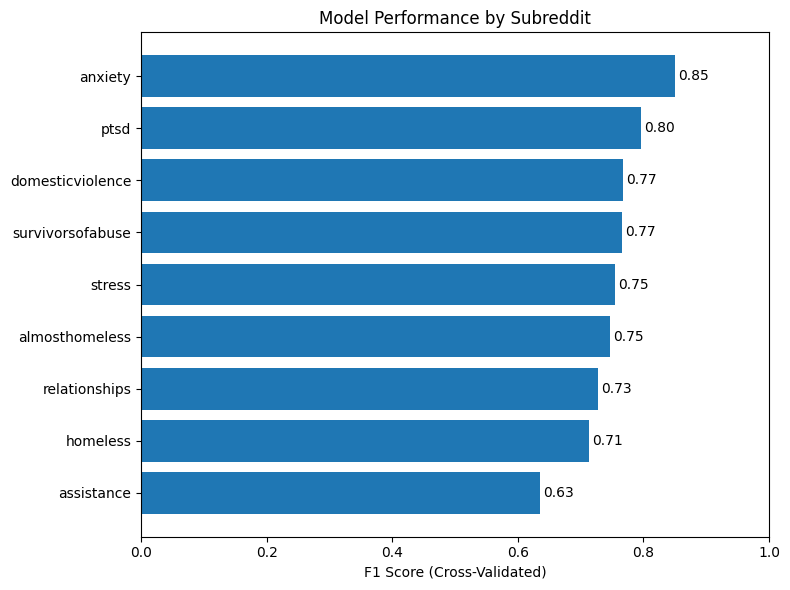

In [29]:
plt.figure(figsize=(8,6))

bars = plt.barh(
    subreddit_f1_filtered["subreddit"],
    subreddit_f1_filtered["F1"]
)

plt.xlabel("F1 Score (Cross-Validated)")
plt.title("Model Performance by Subreddit")
plt.gca().invert_yaxis()

# Add F1 labels to bars
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.005,                
        bar.get_y() + bar.get_height()/2,
        f"{width:.2f}",               
        va="center"
    )

plt.xlim(0, 1)  
plt.tight_layout()
plt.show()

### Interpretation of Subreddit-Level Variation

Model performance varies substantially across subreddits, with F1-scores ranging from 0.63 (assistance) to 0.85 (anxiety). Subreddits explicitly focused on mental health, such as anxiety and ptsd, exhibit the highest performance of F1 scores of 0.85 and 0.80 respectively. This likely reflects more consistent and linguistically explicit expressions of distress, where users openly describe emotional states, symptoms, or psychological experiences.

In contrast, lower performance is observed in communities such as assistance and homeless, where posts often combine practical resource requests with varying levels of emotional disclosure. In these contexts, stress may be implied rather than explicitly articulated, or embedded within narratives focused on financial, housing, or logistical concerns. Such mixed-intent content may blur the distinction between stressed and non-stressed posts, making classification more challenging.

The magnitude of variation suggests that the model partially benefits from community-specific linguistic norms. Stress appears more detectable in communities centred on mental health discourse than in broader support or resource-oriented spaces. This has important implications for generalisation: a model trained across heterogeneous communities may perform unevenly when applied to new contexts where stress expression differs in tone, explicitness, or narrative framing.

## 4.2 Confidence-Based Error Analysis
To better understand model limitations, we examine high-confidence false positives and false negatives using out-of-fold predicted probabilities. These cases are particularly informative, as they reveal systematic patterns in model misclassification rather than random error.

<Axes: >

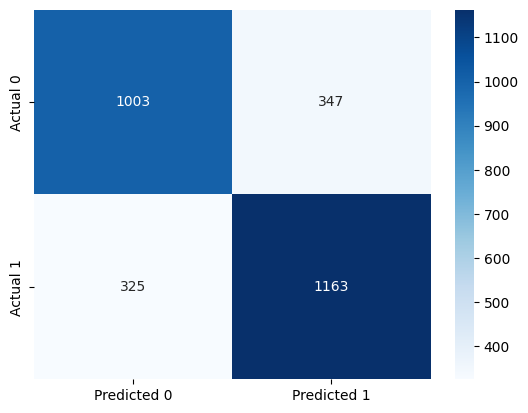

In [30]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(train_df["label"], train_df["oof_pred"])
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted 0", "Predicted 1"],
    yticklabels=["Actual 0", "Actual 1"]
)

In [31]:
from sklearn.metrics import precision_score, recall_score

precision = precision_score(train_df["label"], train_df["oof_pred"])
recall = recall_score(train_df["label"], train_df["oof_pred"])

precision, recall


(np.float64(0.7701986754966887), np.float64(0.7815860215053764))

### Quantitative Error Overview

Across cross-validated predictions, the model achieves a precision of 0.770 and recall of 0.782 for the stressed class. The confusion matrix shows a relatively balanced distribution of false positives (347) and false negatives (325), indicating that the model does not exhibit strong asymmetry in error type. However, approximately 22% of stressed posts remain undetected, underscoring the importance of examining failure modes more closely.

In [32]:
from sklearn.model_selection import cross_val_predict

# Get out-of-fold predicted probabilities
oof_probs = cross_val_predict(
    pipeline_combined,
    train_df,
    train_df["label"],
    cv=cv,
    method="predict_proba"
)

train_df["oof_prob"] = oof_probs[:, 1]  # probability of stressed class

In [33]:
# False positives
false_pos = train_df[
    (train_df["label"] == 0) &
    (train_df["oof_pred"] == 1)
]

# False negatives
false_neg = train_df[
    (train_df["label"] == 1) &
    (train_df["oof_pred"] == 0)
]

In [34]:
# high confidence false positives
high_conf_fp = false_pos.sort_values(
    by="oof_prob",
    ascending=False
).head(5)
high_conf_fp[["text", "oof_prob"]]


,text,oof_prob
2400,Yet I’ve already been through the worst and co...,0.983046
1828,I feel really guilty over it. I know part of t...,0.979247
2321,"I started freaking out, went to the hospital b...",0.976259
406,Picked music up again and I'm considering the ...,0.942336
1264,"Ever since I left school, I’ve felt much more ...",0.934855


In [35]:
# high confidence false negatives
high_conf_fn = false_neg.sort_values(
    by="oof_prob",
    ascending=True
).head(5)
high_conf_fn[["text", "oof_prob"]]

,text,oof_prob
2828,Accounts incredibly overdue. A life entirely u...,0.042874
1283,I'm worried about my friend. She's really pret...,0.060763
2599,The messages are essentially the guy being fli...,0.070742
2451,"Hi, My partner is a Dv survivor after 15 years...",0.081259
1425,It honestly felt like someone punched a hole r...,0.089045


In [36]:
for idx, row in high_conf_fp.iterrows():
    print("---- FALSE POSITIVE ----")
    print("Prob:", round(row["oof_prob"], 3))
    print("Subreddit:", row["subreddit"])
    print("Text:", row["text"][:500])
    print("\n")

---- FALSE POSITIVE ----
Prob: 0.983
Subreddit: domesticviolence
Text: Yet I’ve already been through the worst and come out smarter and stronger. I’m not so afraid that I’m just running and not fighting it anymore. So WHAT exactly am I afraid of? WHAT is the reason of this fear? I mean what’s the worst that will happen and how can it be any worse than what he’s already put me through.


---- FALSE POSITIVE ----
Prob: 0.979
Subreddit: ptsd
Text: I feel really guilty over it. I know part of the problem may be how much I've repressed and can't feel, but... I don't know, I feel I've exaggerated so much. I haven't been having nightmares, and my "flashbacks" don't feel like flashbacks so much as "regressive anxious states." I can think of the trauma I've been through and talk about it, but it doesn't feel like anything disturbing.


---- FALSE POSITIVE ----
Prob: 0.976
Subreddit: ptsd
Text: I started freaking out, went to the hospital because I couldn't breath. Occasionally I still feel anxi

In [37]:
for idx, row in high_conf_fn.iterrows():
    print("---- FALSE NEGATIVE ----")
    print("Prob:", round(float(row["oof_prob"]), 3))
    print("Subreddit:", row["subreddit"])
    print("Text:", row["text"][:500])
    print("\n")

---- FALSE NEGATIVE ----
Prob: 0.043
Subreddit: domesticviolence
Text: Accounts incredibly overdue. A life entirely unattended to, without organization or care. Chaos. I knew none of this. The man he presented to me was one of principle (honesty, loyalty, your word is your bond, etc), always ready to protect and serve in whatever way necessary.


---- FALSE NEGATIVE ----
Prob: 0.061
Subreddit: relationships
Text: I'm worried about my friend. She's really pretty and carefree and intelligent and I've known her since highschool. We had a band back then. She played guitar and sang, I played bass and another friend of ours played drums. We were into the grunge scene and to be honest, we were kinda good for a bunch of 15 year olds trying to make a name for themselves.


---- FALSE NEGATIVE ----
Prob: 0.071
Subreddit: relationships
Text: The messages are essentially the guy being flirtatious and asking her to come over to his place. My gf’s responses are not flirtatious but definitely welcomi

### High-Confidence False Positives

Several high-confidence false positives occur in posts containing emotionally intense vocabulary (e.g., “fear,” “trauma,” “anxiety,” “PTSD”) yet labelled as non-stressed. In many cases, users reflect on past trauma, describe recovery, or frame experiences within resilience and growth. For instance, some posts explicitly acknowledge having “been through the worst and come out stronger,” signalling resolution rather than ongoing distress.

These cases suggest that the model assigns strong positive weight to emotionally salient lexical cues but lacks temporal and contextual awareness. It appears sensitive to the presence of distress-related words, yet less capable of distinguishing between current emotional suffering and retrospective reflection. In effect, the model conflates the topic, which is the discussion of trauma, with the author's present state of stress. This reveals a limitation of surface-level lexical modelling: it captures what is being discussed, but not necessarily the writer’s current psychological condition.

### High-Confidence False Negatives

High-confidence false negatives frequently involve distress expressed implicitly through narrative structure rather than explicit emotional terms. Examples include descriptions of unstable living situations, relationship betrayal, or domestic conflict where emotional language is restrained, understated, or cognitively framed.

In these instances, stress is conveyed through situational complexity and relational tension rather than overt affective vocabulary. The model appears less sensitive to such contextualised or implied distress, likely because its predictive signals rely heavily on explicit lexical indicators (e.g., negative emotion words or self-referential language). When distress is communicated through subtle narrative accumulation rather than direct emotional labelling, the signal becomes diluted.

### Implications

Together, these findings suggest that the model performs reliably when stress is linguistically explicit but struggles when stress is temporally resolved or narratively embedded. This asymmetry reflects a broader limitation of bag-of-words style representations: they prioritise frequency and salience of terms but lack deeper discourse-level understanding.

In real-world deployment, this means the model may over-flag posts that discuss trauma in reflective contexts while under-detecting individuals who express distress indirectly or with emotional restraint. As a result, the system is better understood as detecting expressed affect rather than underlying psychological vulnerability.

## 4.3 Linguistic Feature Interpretation
To further understand how the model distinguishes stressed from non-stressed posts, we examine the most influential features from the logistic regression classifier. As a linear model, logistic regression provides direct interpretability through its feature coefficients, allowing us to identify which words and phrases most strongly increase or decrease the likelihood of predicting stress. This analysis helps clarify the linguistic patterns driving model decisions and connects predictive performance to underlying psychological signals.

In [38]:
pipeline_combined.fit(train_df, train_df["label"])

# Get text feature names
tfidf_feature_names = (
    pipeline_combined.named_steps["preprocessor"]
    .named_transformers_["text"]
    .get_feature_names_out()
)

# Get numeric feature names
numeric_feature_names = liwc_features

# Combine feature names
all_feature_names = list(tfidf_feature_names) + numeric_feature_names


coefficients = pipeline_combined.named_steps["clf"].coef_[0]

coef_df = pd.DataFrame({
    "feature": all_feature_names,
    "coefficient": coefficients
})

coef_df = coef_df.sort_values(by="coefficient", ascending=False)

In [39]:
# Top stress predictors (positive coefficients)
top_stress = coef_df.head(20)
top_stress

,feature,coefficient
4910,me,2.488533
2125,do,1.664472
2404,even,1.637623
8344,to do,1.560040
5217,my,1.528974
9186,what to,1.487684
5419,need,1.477131
2213,don know,1.307515
2204,don,1.304212
4353,just,1.253231


In [40]:
# Top non-stress predictors (negative coefficients)
top_non_stress = coef_df.tail(20).sort_values(by="coefficient")
top_non_stress

,feature,coefficient
9574,you,-1.712939
7572,that,-1.326769
9061,we,-1.171335
5056,met,-1.037530
9543,years,-0.995297
9149,were,-0.959302
9632,your,-0.923756
9197,when,-0.891477
2668,finally,-0.829765
6158,person,-0.828210


Inspection of the logistic regression coefficients reveals that the strongest predictors of stress are dominated by first-person, self-referential language, including terms such as “me,” “my,” “am,” “feel,” and “need.” Several bigram features (e.g., “need to,” “what to,” and “don know”) reflect experiential and problem-focused phrasing. These patterns suggest that stress-related posts are characterised by heightened self-focus, uncertainty, and internal reflection.

From a modelling perspective, logistic regression assigns positive weight to features that consistently co-occur with the stressed label. The prominence of these self-referential terms indicates that the classifier is detecting patterns of inward attentional focus rather than specific stress topics. In other words, the model appears to respond more strongly to how experiences are narrated (self-oriented and uncertainty-driven) than to the concrete events being described.

Conversely, strong predictors of the non-stressed class include outward-facing and relational language such as “you,” “your,” “we,” and “people.” These features are consistent with conversational, advisory, or descriptive tones, where attention is directed toward others rather than internal emotional states.

The prominence of first-person singular pronouns in stress prediction aligns with psycholinguistic research linking self-referential language to psychological distress (Tausczik & Pennebaker, 2010). However, this also highlights a structural limitation: the model operationalises stress largely through explicit linguistic markers of self-focus and affect. As observed in the earlier error analysis, posts that convey distress indirectly — through narrative complexity, restrained tone, or situational accumulation — may not trigger these high-weight lexical signals.

Taken together, the coefficient analysis suggests that the model is best understood as detecting linguistic patterns of inward cognitive and emotional focus. While effective when stress is overtly expressed, this representation may underperform when distress is implicit, socially moderated, or framed in reflective language.

## 4.4 Ambiguous or Borderline Case Analysis
Beyond clear misclassifications, it is also informative to examine posts whose predicted probabilities lie close to the decision threshold (0.5), between 0.45 and 0.55. These borderline cases represent instances where the model expresses the least confidence in its classification. Analysing such examples provides insight into how stress is linguistically constructed and whether ambiguity arises from model limitations or from the inherently graded nature of psychological distress.

In [41]:
borderline = train_df[
    (train_df["oof_prob"] > 0.45) &
    (train_df["oof_prob"] < 0.55)
]

len(borderline)

272

In [53]:
for _, row in borderline.sample(5, random_state=42).iterrows():
    print("---- BORDERLINE CASE ----")
    print("Prob:", round(row["oof_prob"], 3))
    print("Subreddit:", row["subreddit"])
    print("Label:", row["label"])
    print("Text:", row["text"][:500])
    print()

---- BORDERLINE CASE ----
Prob: 0.542
Subreddit: ptsd
Label: 0
Text: Asked for a little extension. She won’t provide it. I should be able to graduate in December. My academic counselor is looking to help me graduate around some of the program, so I hate to bring my concerns up higher or file with disability. My trauma therapist wants me to advocate higher up.

---- BORDERLINE CASE ----
Prob: 0.464
Subreddit: survivorsofabuse
Label: 1
Text: But if I want to be successful at networking and forming close friendships/relationships, I need to get rid of this phobia somehow. In some ways, my fear is interfering with not just my social life, but my academics as well. I earn high grades but if I want to snatch opportunities outside of the classroom, I need to suck it up and try to tolerate group work with my classmates more. I opened up to a therapist about this, but before we could actually discuss ways on how to combat the problem, she 

---- BORDERLINE CASE ----
Prob: 0.546
Subreddit: assis

### Analysis of Borderline Cases
To better understand model uncertainty, we examine posts with predicted probabilities closest to the 0.5 decision threshold. These cases represent instances where the model detects competing linguistic signals from both classes.

Several borderline cases labelled as non-stressed (e.g., the PTSD subreddit post with probability 0.542) describe challenging institutional or therapeutic situations. Although the author references trauma therapy and advocacy, the tone remains pragmatic and problem-solving rather than emotionally distressed. The language focuses on academic planning (“graduate in December”), procedural concerns (“file with disability”), and coordination with counsellors. This mixture of trauma-related context with measured, goal-oriented phrasing appears to push the probability slightly above 0.5 without generating strong stress confidence.

Conversely, stressed borderline examples (e.g., probability 0.464 in the survivorsofabuse subreddit) describe internal struggles such as social phobia and fear interfering with academic and relational functioning. However, these posts are articulated in reflective and future-oriented language (“I need to get rid of this phobia,” “I earn high grades but…”). The presence of self-improvement framing and structured reasoning may moderate the model’s confidence despite clear underlying distress.

Another stressed borderline case (probability 0.546) involves an urgent housing emergency. While the content reflects situational crisis (“losing my housing on Friday”), the phrasing is largely informational and request-oriented (“ISO a room for rent,” “not looking for full houses”). The absence of intense affective vocabulary appears to limit how strongly the model associates it with psychological stress.

Similarly, a non-stressed relationship post (probability 0.455) discusses breakups and emotional tension but maintains a conversational and narrative tone focused on relational dynamics rather than acute distress.

Taken together, these cases suggest that model uncertainty emerges when adversity-related content coexists with regulated, pragmatic, or socially oriented language. The classifier appears sensitive to references to trauma, emergency, or relational difficulty, yet its confidence increases primarily when such experiences are accompanied by explicit emotional intensity or inward-focused distress signals.

### Implications
These examples reinforce that borderline predictions are not random noise but reflect structured ambiguity in how stress is expressed. Posts that describe difficult circumstances in a composed or solution-focused manner may receive intermediate probabilities, even when the underlying situation is serious. Conversely, emotionally charged topics without clear markers of current psychological strain may also fall near the threshold.

This highlights a fundamental limitation of binary classification in mental health contexts: distress is often situational, graded, and narratively framed, whereas the model must compress this complexity into a single probability and discrete decision. In real-world deployment, predictions near the decision boundary may therefore warrant human review rather than automatic action, particularly in sensitive settings such as mental health moderation or support triage.

# Stage 5: Clinical Ethics Considerations

## 5.1 Deployment Framing

The predictive model developed in this study demonstrates reasonably strong performance in distinguishing stressed from non-stressed Reddit posts. However, deploying such a system in real-world settings — such as online mental health monitoring, community moderation, or early distress detection initiatives — requires careful consideration beyond aggregate performance metrics.

The analyses conducted in Stage 4 reveal that model performance varies across communities, depends heavily on explicit experiential language, and exhibits uncertainty when distress is expressed in moderated or narrative forms. These characteristics shape both the potential benefits and risks of deployment.

Additionally, this model should not be interpreted as a clinical diagnostic instrument, but rather as a probabilistic triage system designed to assist human judgement.

## 5.2 False Negatives: Under-Detection of Distress

The model achieves a recall of 0.782, meaning approximately 22% of stressed posts remain undetected. Error and borderline analyses indicate that false negatives frequently occur when distress is embedded within situational narratives rather than articulated through intense affective vocabulary. High-functioning individuals or those expressing distress in reflective, regulated language may receive lower predicted probabilities.

In a real-world deployment context, false negatives may be particularly concerning, as they represent missed opportunities to identify individuals experiencing genuine distress. This limitation underscores the importance of complementing automated detection systems with human oversight or alternative support mechanisms.

## 5.3 False Positives: Over-Flagging and Context Misinterpretation

False positives tend to occur when emotionally salient vocabulary appears in reflective or recovery-oriented contexts. Posts discussing past trauma or resilience may be classified as stressed due to lexical cues despite the absence of acute distress.

In deployment, over-flagging could lead to unnecessary interventions, alert fatigue among moderators, or erosion of user trust. Particularly in sensitive domains, automated systems must avoid pathologising normal emotional expression or reflective storytelling.

## 5.4 Threshold Sensitivity and Ambiguity

Borderline cases highlight the limitations of a fixed binary decision threshold. Stress expression often exists along a continuum, and probabilities near 0.5 may reflect genuine ambiguity rather than clear misclassification. Adjusting the classification threshold would alter the balance between precision and recall, directly influencing the rate of false negatives and false positives.

Therefore, threshold selection should be guided by deployment objectives. In settings that prioritise early intervention, a lower threshold may be justified to increase recall, albeit at the cost of increased false positives. Conversely, contexts that require high confidence before action may favour a higher threshold. The acceptable balance between false negatives and false positives ultimately depends on normative and contextual judgments about harm, resource availability, and intervention consequences.

## 5.5 Risks of Automated Surveillance

The use of predictive models for mental health detection raises broader ethical concerns, including privacy, autonomy, and unintended surveillance. Automated monitoring of user-generated content may create perceptions of constant observation, potentially altering how individuals express themselves online. Furthermore, algorithmic decisions risk reinforcing biases if stress is detected more easily in certain communities or linguistic styles than others. Since the model is trained exclusively on Reddit communities, its learned associations may not generalise to other cultural or linguistic contexts (e.g., Singapore), where stress expression patterns, norms of disclosure, and language use may differ substantially.

As discussed by Mittelstadt et al. (2016), algorithmic systems in sensitive domains require careful governance to prevent unintended harms, especially when deployed at a larger scale.

## 5.6 Human-in-the-Loop Recommendation

Given the observed variation across subreddits, reliance on explicit lexical cues, and ambiguity in borderline cases, this model is best suited as a decision-support tool rather than an autonomous intervention system. Predictions — particularly those near the decision threshold — could be used to prioritise posts for human review rather than to trigger automated actions.

A human-in-the-loop approach would allow moderators or mental health professionals to incorporate contextual understanding, nuance, and ethical judgement that cannot be fully captured by lexical modelling alone.

# Stage 6: Hyperparameter Optimisation

To ensure that the final reported performance reflects a well-tuned model rather than default parameter choices, hyperparameters were optimised using grid search with stratified 5-fold cross-validation on the training set. The search space included regularisation strength (C) for logistic regression and text representation parameters (n-gram range and minimum document frequency) for the TF-IDF vectoriser. The held-out test set remained strictly untouched during this process.

In [43]:
param_grid = {
    "preprocessor__text__ngram_range": [(1,1), (1,2)],
    "preprocessor__text__min_df": [3, 5],
    "clf__C": [0.1, 1, 10]
}

In [44]:
LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    solver="liblinear",
    random_state=42
)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42,
                   solver='liblinear')

In [45]:
from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(
    pipeline_combined,
    param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

grid.fit(train_df, train_df["label"])

print("Best Parameters:", grid.best_params_)
print("Best CV F1:", grid.best_score_)


Best Parameters: {'clf__C': 1, 'preprocessor__text__min_df': 3, 'preprocessor__text__ngram_range': (1, 1)}
Best CV F1: 0.7769420966833591


In [46]:
best_model = grid.best_estimator_

The best-performing configuration achieved a cross-validated F1-score of 0.777, with parameters:
- Regularisation strength C = 1
- Minimum document frequency min_df = 3
- Unigram features only (1,1)

Notably, unigram features slightly outperformed bigrams, suggesting that stress-related signal in this dataset is primarily captured through individual lexical markers rather than multi-word phrase structure.

# Stage 7: Model Interpretability (SHAP)

While performance metrics quantify how well the model distinguishes stressed from non-stressed posts, they do not explain why specific predictions are made. In a sensitive domain such as mental health detection, interpretability is essential to ensure transparency, accountability, and responsible deployment. To better understand the model’s decision-making process, we apply SHAP (SHapley Additive exPlanations), a method that quantifies the contribution of each feature to individual predictions.

SHAP provides both global insight into which features are most influential overall and directional information about how high or low feature values shift predictions toward stress or non-stress. This allows us to verify whether the model is capturing psychologically meaningful patterns rather than relying on superficial keyword associations.

In [47]:
best_model.fit(train_df, train_df["label"])

# TF-IDF feature names
tfidf_feature_names = (
    best_model.named_steps["preprocessor"]
    .named_transformers_["text"]
    .get_feature_names_out()
)

# Numeric feature names (LIWC + sentiment + readability)
numeric_feature_names = liwc_features  

all_feature_names = list(tfidf_feature_names) + list(numeric_feature_names)

In [48]:
X_train_trans = best_model.named_steps["preprocessor"].transform(train_df)

# Use a subset for SHAP
n_shap = min(500, train_df.shape[0])
X_shap = X_train_trans[:n_shap]

In [49]:
import shap

explainer = shap.LinearExplainer(
    best_model.named_steps["clf"],
    X_shap,                 
    feature_perturbation="interventional"
)

shap_values = explainer.shap_values(X_shap)

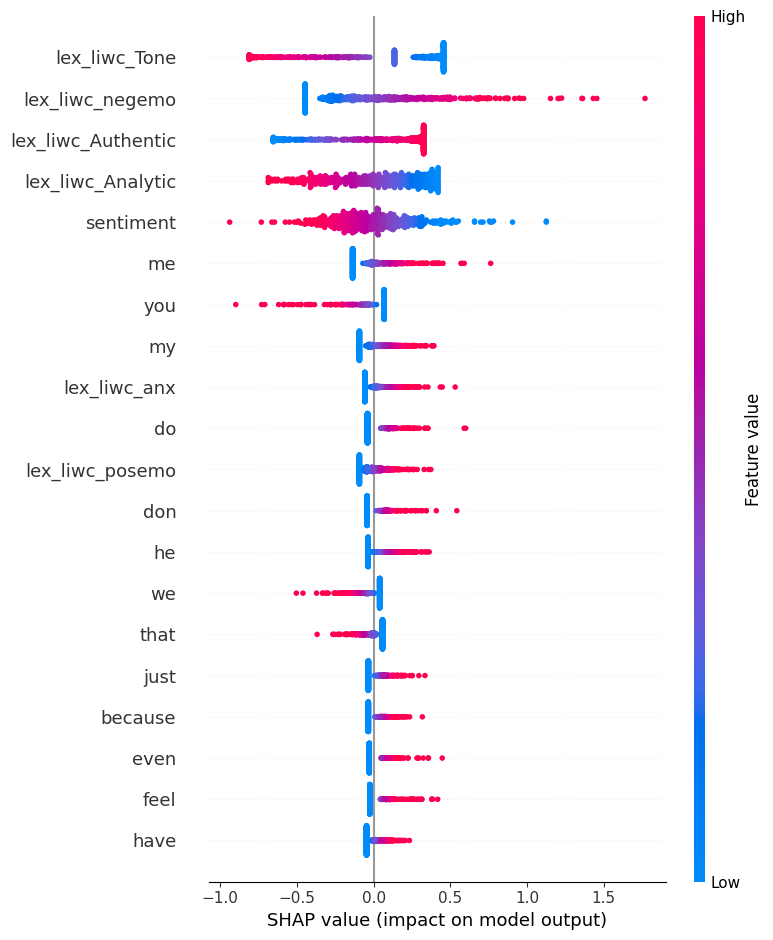

In [50]:
# Convert sparse matrix to dense for SHAP plotting
X_shap_dense = X_shap.toarray()

shap.summary_plot(
    shap_values,
    X_shap_dense,
    feature_names=all_feature_names
)


The SHAP summary plot provides a global explanation of the final tuned model by quantifying how each feature contributes to predictions across all posts. Emotional tone (lex_liwc_Tone) emerges as the most influential feature at the top of the plot. Posts with lower emotional tone (blue values) push predictions strongly toward the stressed class on the right, while posts with higher positive tone shift predictions toward non-stress on the left side. This indicates that emotional tone plays a central role in how the model detects stress signals.

Negative emotion (lex_liwc_negemo) shows the complementary directional pattern: higher negative emotion values increase the probability of stress classification. This aligns with established psychological understanding that heightened negative affect often accompanies distress expression. Importantly, tone and negative emotion do not operate in isolation but interact with broader linguistic patterns.

Interestingly, stylistic features such as Authenticity and Analytic thinking also contribute meaningfully. Higher authenticity values push predictions toward stress, suggesting that stressed posts may be more confessional and emotionally direct. Conversely, higher analytic scores shift predictions toward non-stress, indicating that structured, logical language may signal greater emotional regulation or narrative distancing from distress.

Self-referential markers such as “me” and “my” further increase stress probability, reinforcing earlier findings that stress expression tends to be inward-focused. Outward-facing pronouns such as “you” and “we” exhibit weaker or opposite effects, shifting predictions toward non-stress. This pattern suggests that the model captures not only emotional intensity but also narrative perspective and attentional focus.

While SHAP improves transparency, it is important to recognise that it reveals statistical associations learned from the data rather than causal psychological mechanisms. Features such as authenticity or self-focus may correlate with stress expression in Reddit posts, but they do not imply that these traits cause stress.

Notably, earlier error analysis showed that posts describing objectively stressful events in a relatively neutral tone were sometimes misclassified. This indicates that the model relies substantially on affective and stylistic cues, and may under-detect emotionally muted or cognitively framed distress narratives.

Overall, the SHAP analysis demonstrates that the model integrates affective tone, linguistic style, and lexical self-focus rather than relying solely on isolated keywords. This level of interpretability is particularly important in sensitive mental-health applications, as it provides transparent justification for predictions while also revealing potential blind spots that must be considered before deployment.

Having finalised the model architecture and hyperparameters using cross-validation in the previous sections, we now evaluate its performance on the held-out test set to assess how well it generalises to unseen data.

# Stage 8: Final Evaluation on Held-Out Test Set

In [51]:
# Fit best model on full training data
best_model.fit(train_df, train_df["label"])

from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix, classification_report

# Predict on test set
test_preds = best_model.predict(test_df)
test_probs = best_model.predict_proba(test_df)[:,1]

# Metrics
test_f1 = f1_score(test_df["label"], test_preds)
test_precision = precision_score(test_df["label"], test_preds)
test_recall = recall_score(test_df["label"], test_preds)
cm = confusion_matrix(test_df["label"], test_preds)

print("Test F1:", test_f1)
print("Test Precision:", test_precision)
print("Test Recall:", test_recall)
print("Confusion Matrix:\n", cm)

Test F1: 0.7737617135207496
Test Precision: 0.7645502645502645
Test Recall: 0.7831978319783198
Confusion Matrix:
 [[257  89]
 [ 80 289]]


After hyperparameter optimisation, the final tuned model was trained on the full training dataset and evaluated on the held-out test set, which remained strictly unused during model development and selection.

The model achieved:
- F1-score: 0.774
- Precision: 0.765
- Recall: 0.783

The test F1-score (0.774) is highly consistent with the cross-validated training performance (CV F1 = 0.777), with a marginal difference of approximately 0.003. This small deviation lies well within the observed cross-validation variability and suggests that the model generalises effectively to unseen data. There is no indication of substantial overfitting or performance inflation during model development.

The model demonstrates slightly higher recall than precision. This indicates that it captures a majority of stressed posts (approximately 78%) while tolerating a moderate number of false positives. In practical deployment settings — such as online community moderation or early mental health signal detection — this trade-off may be defensible if the objective prioritises identifying potentially distressed individuals over minimising false alerts.

However, the confusion matrix also highlights that approximately 22% of stressed posts remain undetected (false negatives). As observed in earlier error analyses, these cases often involve moderated, reflective, or narratively embedded distress rather than overt emotional language. This suggests that while the model performs well quantitatively, certain forms of subtle or high-functioning stress remain challenging to detect through lexical modelling alone.

Overall, the final evaluation confirms that the model achieves stable and generalisable predictive performance, while also reinforcing the nuanced limitations identified during subgroup and error analyses.

# Final Conclusion
This study developed and evaluated a predictive model for detecting stress signals in Reddit posts using the Dreaddit dataset. Through systematic comparison of text-only, LIWC-only, and combined feature models, we found that detailed lexical patterns capture the majority of predictive signal, while psychologically grounded summary features provide complementary and incremental improvements. The final tuned logistic regression model achieved stable and generalisable performance (Test F1 = 0.774), closely aligned with cross-validated estimates, indicating minimal overfitting.

Interpretability analyses using SHAP revealed that the model’s decisions are driven primarily by affective tone, negative emotion, authenticity, analytic style, and self-referential language. This confirms that stress detection is not merely keyword spotting, but reflects broader linguistic and psychological patterns. Importantly, the model integrates emotional intensity, stylistic structure, and lexical self-focus in a coherent manner, increasing transparency and trustworthiness in a sensitive mental health context.

Subgroup analysis further demonstrated variation in predictive performance across subreddits, suggesting that community norms and topical framing influence how stress is expressed linguistically. Error and borderline case analyses revealed that misclassifications often occur in posts where distress is moderated, narratively embedded, or expressed in reflective rather than overtly emotional language. These findings highlight that stress expression exists on a continuum rather than as a binary state, posing inherent limitations for any classification-based approach.

From a deployment perspective, the model’s slightly higher recall than precision suggests it may be suitable as a supportive screening or triage tool rather than a definitive diagnostic system. However, the presence of false negatives underscores the ethical risk of missing subtle distress, while false positives raise concerns about over-flagging and potential stigma. Any real-world implementation — for example, within online community moderation or public mental health monitoring initiatives — should therefore prioritise transparency, human oversight, and clear communication regarding system limitations.

Overall, this project demonstrates that predictive modelling can meaningfully translate informal digital expression into structured signals of stress, but also that such translation is probabilistic, context-dependent, and ethically complex. Quantitative performance metrics must therefore be interpreted alongside linguistic nuance, community dynamics, and responsible deployment considerations.

# References
1. Boyd, R. L., Jr., Ashokkumar, A., Seraj, S., Pennebaker, J. W., & The University of Texas at Austin. (2022). The development and Psychometric Properties of LIWC-22. University of Texas at Austin. https://www.liwc.app/static/documents/LIWC-22%20Manual%20-%20Development%20and%20Psychometrics.pdf 
2. Mittelstadt, B. D., Allo, P., Taddeo, M., Wachter, S., & Floridi, L. (2016). The ethics of algorithms: Mapping the debate. Big Data & Society, 3(2). https://doi.org/10.1177/2053951716679679 
3. Tausczik, Y. R., Pennebaker, J. W., James J. Bradac, & University of Texas at Austin. (2010). The Psychological Meaning of Words: LIWC and Computerized Text Analysis Methods. In Journal of Language and Social Psychology (Vol. 29, Issue 1, pp. 24–54). SAGE Publications. https://doi.org/10.1177/0261927X09351676
4. Wang, S. I., & Manning, C. D. (2012, July 1). Baselines and bigrams: simple, good sentiment and topic classification. ACL Anthology. https://aclanthology.org/P12-2018/ 